In [1]:
import os
import time
from datetime import datetime
import sys
try:
    import phasebalance.phase_unbalance_utils as m
    import phasebalance.janitza_report_device as jrd
except ModuleNotFoundError:
    sys.path.insert(0, os.path.join(os.getcwd(), ".."))
    import src.phasebalance.phase_unbalance_utils as m
    import src.phasebalance.janitza_report_device as jrd
from typing import Optional, Tuple
import pandas as pd
import numpy as np
import re
from typing import Sequence, Optional, Tuple
try:
    import matplotlib.pyplot as plt
    from matplotlib.patches import Circle
except Exception:  # matplotlib not available
    plt = None
    Circle = None

PATTERN = (
    r"Measurement Group 2|Measurement Group 3|Mod 1|Mod1|Mod2|Mod3|Mod\. 1|Mod\. 2|LR|241|"
    r"Device-4|Device-233|Device-162"
)

# first segment is like: D0411 SP2 L1
_NAME_RE = re.compile(r"^\s*D0*(\d+)\s+(SP\d+)\s+(L\d+)\s*$", re.IGNORECASE)

def parse_device_name(name: str) -> str:
    """
    Examples:
      'D0411 SP2 L1 / ...' -> '411 SP2'
      'D0029 SP1 L2'       -> '29 SP1 L2'   # edge case: keep L2, but L1 is dropped everywhere
    """
    if name is None or (isinstance(name, float) and pd.isna(name)):
        return name

    first = str(name).split(" / ", 1)[0].strip()
    m = _NAME_RE.match(first)
    if not m:
        return first  # fallback: still removed the trailing junk

    substation = str(int(m.group(1)))   # remove leading zeros
    sp = m.group(2).upper()
    lx = m.group(3).upper()

    # Drop L1, keep L2 (only one device uses L2)
    return f"{substation} {sp}" if lx == "L1" else f"{substation} {sp} {lx}"

def _severity_donut_for_metric(
    df: pd.DataFrame,
    metric: str,
    threshold: float,      # kept for API-compatibility; intentionally unused
    outdir: str,           # kept for API-compatibility; intentionally unused
    per_device: bool = True,
    agg: str = "median",
    labels: Tuple[str, str, str, str] = ("Low", "Medium", "High", "Extreme"),
    *,
    low: float = 0.15,
    mid: float = 0.30,
    high: float = 0.50,
):
    """
    Doughnut chart showing severity breakdown for `metric`.

    Bins (custom edges):
      Low     : value < low
      Medium  : low <= value < mid
      High    : mid <= value < high
      Extreme : value >= high

    Notes:
    - `threshold` and `outdir` are accepted to keep the same call signature as before,
      but are not used.
    """
    if plt is None or Circle is None:
        print("matplotlib not available; skipping severity doughnut.")
        return None
    if metric not in df.columns:
        print(f"[{metric}] not found; skipping severity doughnut.")
        return None

    # sanity check for thresholds
    low = float(low)
    mid = float(mid)
    high = float(high)
    if not (low < mid < high):
        raise ValueError(f"Expected low < mid < high, got low={low}, mid={mid}, high={high}")

    # choose the series to bin
    ser = pd.to_numeric(df[metric], errors="coerce").dropna()
    if ser.empty:
        print(f"[{metric}] no numeric values; skipping severity doughnut.")
        return None

    if per_device and "device_id" in df.columns:
        g = df.dropna(subset=[metric]).copy()
        g[metric] = pd.to_numeric(g[metric], errors="coerce")

        agg_map = {"median": "median", "mean": "mean", "max": "max", "min": "min"}
        if agg not in agg_map:
            raise ValueError(f"Unsupported agg='{agg}'")

        ser = getattr(g.groupby("device_id")[metric], agg_map[agg])().dropna()

    if ser.empty:
        print(f"[{metric}] aggregation produced no data; skipping.")
        return None

    # 4 bins: (-inf, low), [low, mid), [mid, high), [high, +inf)
    bins = [float("-inf"), low, mid, high, float("inf")]
    cats = pd.cut(
        ser.astype(float).to_numpy(),
        bins=bins,
        labels=list(labels),
        right=False,
        include_lowest=True,
    )

    counts = pd.Series(cats).value_counts().reindex(list(labels), fill_value=0)
    if int(counts.sum()) == 0:
        print(f"[{metric}] no counts in any bin; skipping.")
        return None

    counts_np = counts.astype(int).to_numpy()
    total = int(counts_np.sum())

    # Colors: green / amber / red / purple
    colors = ["#a8d5a2", "#f6c270", "#e07070", "#9b59b6"]

    fig, ax = plt.subplots(figsize=(6, 5))

    legend_labels = [
        f"{lab}  ({n} supply points, {n/total*100:.1f}%)"
        for lab, n in zip(counts.index, counts_np)
    ]

    wedges, _ = ax.pie(
        counts_np,
        labels=None,
        startangle=90,
        colors=colors,
        wedgeprops=dict(width=0.45, edgecolor="white", linewidth=1.5),
        counterclock=False,
    )

    # centre annotation: total N
    ax.text(0, 0, f"N = {total}", ha="center", va="center",
            fontsize=13, fontweight="bold", color="#333333")

    ax.legend(
        wedges,
        legend_labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=2,
        frameon=False,
        fontsize=9,
        title=f"Severity  (Low<{low}%, Med<{mid}%, High<{high}%)",
        title_fontsize=8,
    )

    ax.axis("equal")

    _metric_names = {
        "cur_ratio": "CUR",
        "cur_dev_ratio": "CUR Deviation",
        "vuf_magnitude": "VUF",
    }
    metric_display = _metric_names.get(metric, metric)
    scope = f"per-supply point {agg.capitalize()}" if per_device else "all rows"
    ax.set_title(
        f"{metric_display} — severity breakdown({scope})",
        fontsize=11, fontweight="bold", pad=10,
    )

    fig.tight_layout()
    return fig

def barplot_by_device(
    df: pd.DataFrame,
    metric: str,
    outdir: str,                 # kept for API-compatibility; intentionally unused
    top_n: int | None = None,
    *,
    name_df: pd.DataFrame | None = None,   # <- pass df_jn_filtered here
    name_col: str = "name",
):
    """
    Bar chart of `metric` vs device label.
    If name_df is provided (e.g. df_jn_filtered), x-axis shows parsed `name` instead of device_id.
    """
    if plt is None:
        print("matplotlib not available; skipping plots.")
        return None
    if metric not in df.columns:
        print(f"[{metric}] metric column missing; skipping.")
        return None

    # ---- Find device ids (column OR index) ----
    candidates = ("device_id", "deviceId", "deviceID", "Device_ID", "DeviceId")
    cols = {str(c).strip(): c for c in df.columns}
    device_col = next((cols[c] for c in candidates if c in cols), None)

    if device_col is not None:
        device_ids = df[device_col].astype(str)
        metric_vals = pd.to_numeric(df[metric], errors="coerce")
        sub = pd.DataFrame({"device_id": device_ids, metric: metric_vals})
    else:
        # assume index is device_id-like
        if df.index.name in candidates or df.index.name == "device_id" or df.index.name is None:
            sub = df[[metric]].copy()
            sub["device_id"] = sub.index.astype(str)
            sub[metric] = pd.to_numeric(sub[metric], errors="coerce")
            sub = sub[["device_id", metric]]
        else:
            print(f"[{metric}] device_id not found in columns or index; skipping.")
            return None

    sub = sub.dropna(subset=[metric])

    # ---- Build device_id -> label mapping from name_df ----
    label_series = None
    if name_df is not None:
        if "device_id" not in name_df.columns or name_col not in name_df.columns:
            raise KeyError(f"name_df must have columns ['device_id','{name_col}']. Got: {list(name_df.columns)}")
        tmp = name_df[["device_id", name_col]].copy()
        tmp["device_id"] = tmp["device_id"].astype(str).str.strip()
        tmp[name_col] = tmp[name_col].astype(str).str.strip()

        # one label per device_id (take first non-null)
        label_series = (
            tmp.dropna(subset=[name_col])
               .drop_duplicates("device_id")
               .set_index("device_id")[name_col]
        )

    # Choose x labels
    sub["device_id"] = sub["device_id"].astype(str).str.strip()
    if label_series is not None:
        sub["label"] = sub["device_id"].map(label_series).fillna(sub["device_id"])
        xcol = "label"
        xlabel = "name"
    else:
        xcol = "device_id"
        xlabel = "device_id"

    # sort + top_n
    sub = sub.sort_values(metric, ascending=False, kind="mergesort")
    if top_n is not None:
        sub = sub.head(top_n)

    n = len(sub)
    if n == 0:
        print(f"[{metric}] No valid data to plot.")
        return None

    width = min(max(10, int(n * 0.35)), 42)
    height = 5

    _metric_names = {
        "cur_ratio": "CUR (%)",
        "cur_dev_ratio": "CUR Deviation (%)",
        "vuf_magnitude": "VUF (%)",
    }
    metric_display = _metric_names.get(metric, metric)

    fig, ax = plt.subplots(figsize=(width, height))

    values = sub[metric].to_numpy()
    x_labels = sub[xcol].astype(str)

    # Color bars by severity
    bar_colors = []
    for v in values:
        if v >= 50:
            bar_colors.append("#9b59b6")   # purple  – extreme
        elif v >= 30:
            bar_colors.append("#e07070")   # red     – high
        elif v >= 15:
            bar_colors.append("#f6c270")   # amber   – medium
        else:
            bar_colors.append("#a8d5a2")   # green   – low
    ax.bar(x_labels, values, color=bar_colors, edgecolor="white", linewidth=0.6)

    ax.set_ylabel(metric_display, fontsize=10)
    ax.set_xlabel("supply points", fontsize=10)
    ax.set_title(
        f"Top {n} supply points by {metric_display}",
        fontsize=12, fontweight="bold",
    )
    ax.tick_params(axis="x", rotation=60, labelsize=8)
    ax.grid(True, axis="y", linestyle=":", linewidth=0.5, alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()
    return fig

def _select_device(df_jn: pd.DataFrame, device_id) -> pd.DataFrame:
    col = df_jn["device_id"]

    # 1) Try numeric match
    col_num = pd.to_numeric(col, errors="coerce")
    try:
        target_num = float(device_id)
    except Exception:
        target_num = None

    if target_num is not None:
        mask = col_num == target_num
        if mask.any():
            return df_jn.loc[mask].copy()

    # 2) Fallback: string-normalized match (handles " 5", "005", "5.0", "D0005")
    target = str(device_id).strip()
    col_s = col.astype(str).str.strip()

    # if values look like D0411, extract digits
    col_digits = col_s.str.extract(r"(\d+)", expand=False)
    target_digits = pd.Series([target]).str.extract(r"(\d+)", expand=False).iloc[0]

    if pd.notna(target_digits):
        mask = col_digits.fillna("") == target_digits
        if mask.any():
            return df_jn.loc[mask].copy()

    # last resort exact string compare
    mask = col_s == target
    return df_jn.loc[mask].copy()

def df_jn_to_report_df(
    df_jn: pd.DataFrame,
    device_id: int,
    metric_col: str = "cur_ratio",
    stat: str = "avg",                 # use Ia_avg/Ib_avg/... (or "min"/"max")
    start: str | None = None,
    end: str | None = None,
    scale: str = "auto",               # "auto" | "fraction_to_percent" | "none"
) -> pd.DataFrame:
    df = _select_device(df_jn, device_id)
    if df.empty:
        # show what "5" looks like in the column to diagnose immediately
        sample = df_jn["device_id"].astype(str).str.strip().unique()[:30]
        raise ValueError(f"No rows for device_id={device_id}. Sample device_id values: {sample}")

    df["ts"] = pd.to_datetime(df["ts"])
    df = df.set_index("ts").sort_index()

    if start is not None:
        df = df.loc[pd.to_datetime(start):]
    if end is not None:
        df = df.loc[:pd.to_datetime(end)]

    # If you have duplicates on ts (can happen with windowed outputs), keep last or aggregate
    df = df[~df.index.duplicated(keep="last")]

    # Rename chosen stat columns -> Ia/Ib/Ic (and optionally Va/Vb/Vc)
    rename = {
        f"Ia_{stat}": "Ia",
        f"Ib_{stat}": "Ib",
        f"Ic_{stat}": "Ic",
        f"Va_{stat}": "Va",
        f"Vb_{stat}": "Vb",
        f"Vc_{stat}": "Vc",
    }
    missing_curr = [c for c in (f"Ia_{stat}", f"Ib_{stat}", f"Ic_{stat}") if c not in df.columns]
    if missing_curr:
        raise ValueError(f"Missing current columns for stat='{stat}': {missing_curr}")

    df = df.rename(columns={k: v for k, v in rename.items() if k in df.columns})

    # Ensure numeric
    for c in ("Ia", "Ib", "Ic", "Va", "Vb", "Vc"):
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # Build the columns the report expects
    df["I_sum"] = df[["Ia", "Ib", "Ic"]].sum(axis=1)
    df["I_max"] = df[["Ia", "Ib", "Ic"]].max(axis=1)
    df["I_min"] = df[["Ia", "Ib", "Ic"]].min(axis=1)

    if metric_col not in df.columns:
        raise ValueError(f"metric_col='{metric_col}' not in df columns")

    imb = pd.to_numeric(df[metric_col], errors="coerce")

    # Scale: your notebook thresholds (0.15/0.30/0.50) strongly suggest "fraction", not "percent"
    if scale == "fraction_to_percent":
        imb = imb * 100.0
    elif scale == "auto":
        # heuristic: if values look like fractions (<= 2), treat as fraction->percent
        q = float(imb.quantile(0.99)) if imb.notna().any() else np.nan
        if np.isfinite(q) and q <= 2.0:
            imb = imb * 100.0

    df["imbalance"] = imb

    # NOTE: your jrd.label_culprit_pair currently has a bug (see next section).
    # We'll compute culprit_pair robustly here (no need to edit jrd yet).
    def culprit_pair(row):
        hi = row[["Ia","Ib","Ic"]].idxmax()
        lo = row[["Ia","Ib","Ic"]].idxmin()
        canon = {
            "IaIb": "Ia-Ib", "IbIa": "Ia-Ib",
            "IbIc": "Ib-Ic", "IcIb": "Ib-Ic",
            "IcIa": "Ic-Ia", "IaIc": "Ic-Ia",
        }
        return canon.get(f"{hi}{lo}", "Ia-Ib")

    df["dominant_phase"] = df[["Ia", "Ib", "Ic"]].idxmax(axis=1)
    df["culprit_pair"] = df.apply(culprit_pair, axis=1)

    df = df.dropna(subset=["Ia", "Ib", "Ic", "imbalance"])
    return df

def _plot_phase_currents_timeseries(
    df: pd.DataFrame,
    device_id: int,
    dpi: int,
    out_path: str,
    *,
    title: str | None = None,
):
    """
    Plot Ia/Ib/Ic vs timestamp (one device), save to out_path.
    Expects df indexed by ts and containing columns: Ia, Ib, Ic.
    """
    if plt is None:
        print("matplotlib not available; skipping phase current plot.")
        return None

    need = ["Ia", "Ib", "Ic"]
    missing = [c for c in need if c not in df.columns]
    if missing:
        print(f"Missing {missing}; skipping phase current plot.")
        return None

    fig, ax = plt.subplots(figsize=(12, 4), dpi=dpi)
    ax.plot(df.index, df["Ia"], linewidth=1.2, label="Ia")
    ax.plot(df.index, df["Ib"], linewidth=1.2, label="Ib")
    ax.plot(df.index, df["Ic"], linewidth=1.2, label="Ic")

    ax.set_xlabel("Time")
    ax.set_ylabel("Current (A)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")

    if title is None:
        title = f"Device {device_id}: Phase currents"
    ax.set_title(title, fontsize=14, fontweight="bold")

    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi)
    plt.close(fig)
    return fig

def make_7_plots_from_df_jn(
    df_jn: pd.DataFrame,
    device_id: int,
    metric_col: str,
    thresholds: dict,           # mild/moderate/severe in SAME units as df["imbalance"]
    outdir: str,
    dpi: int = 200,
    timebase: str = "15min",
    stat: str = "avg",
    start: str | None = None,
    end: str | None = None,
    scale: str = "auto",
    name_df: pd.DataFrame | None = None,
):
    os.makedirs(outdir, exist_ok=True)

    df = df_jn_to_report_df(
        df_jn, device_id,
        metric_col=metric_col,
        stat=stat,
        start=start, end=end,
        scale=scale,
    )

    # ---- resolve supply point name from name_df (parsed names) ----
    _fname = None
    _ndf = name_df if name_df is not None else df_jn
    if "name" in _ndf.columns:
        _match = (
            _ndf.loc[_ndf["device_id"].astype(str).str.strip() == str(device_id), "name"]
            .dropna().drop_duplicates()
        )
        if not _match.empty:
            _fname = str(_match.iloc[0]).strip()

    sample_delta = jrd._compute_sample_delta(timebase, df.index)

    events_records = {}
    for band, thr in thresholds.items():
            
        if metric_col == "vuf_magnitude" and device_id in VUF_EXCLUDE_DEVICES:
            print(f"Skipping VUF plots for device {device_id} (faulty sensor)")
            continue
        
        ev_idx = jrd.detect_events(
            df["imbalance"],
            tau_on=float(thr),
            tau_off=float(thr) * 0.9,
            gap_merge=1,
            min_len=2,
        )
        events_records[band] = jrd.summarise_events(df, ev_idx, sample_delta)

    mild_events = events_records.get("mild", [])

    # Pick a human-readable metric label
    _metric_names = {
        "cur_ratio": "CUR",
        "cur_dev_ratio": "CUR Deviation",
        "vuf_magnitude": "VUF",
    }
    metric_name = _metric_names.get(metric_col, metric_col) + " (%)"

    # 1) colored time-series (imbalance with culprit colors)
    jrd.plot_colored_cur(
        df, thresholds, device_id, metric_name,
        df.index.min().strftime('%Y-%m-%d'), df.index.max().strftime('%Y-%m-%d'),
        dpi, os.path.join(outdir, "01_colored_cur.png"),
        feeder_name=_fname,
    )

    # 2) phase currents over time (Ia/Ib/Ic)
    _phase_title = f"Supply point {_fname}" if _fname else f"Device {device_id}: Ia/Ib/Ic ({stat})"
    _plot_phase_currents_timeseries(
        df,
        device_id=device_id,
        dpi=dpi,
        out_path=os.path.join(outdir, "02_phase_currents.png"),
        title=_phase_title,
    )

    # shift the old numbering down by +1
    jrd.plot_event_stripes(
        mild_events, device_id, metric_name, df.index.min().strftime('%Y-%m-%d'), df.index.max().strftime('%Y-%m-%d'),
        dpi, os.path.join(outdir, "03_event_stripes.png"), sample_delta,
        feeder_name=_fname,
    )
    jrd.plot_severity_duration_scatter(
        mild_events, device_id, metric_name,
        dpi, os.path.join(outdir, "04_severity_duration_scatter.png"),
        feeder_name=_fname,
    )
    jrd.plot_diurnal_heatmap(
        df, device_id, metric_name,
        dpi, os.path.join(outdir, "05_diurnal_heatmap.png"),
        feeder_name=_fname,
    )

    metrics = {
        "overall_peak": float(df["imbalance"].max()),
        "overall_p95": float(df["imbalance"].quantile(0.95)),
        "overall_p99": float(df["imbalance"].quantile(0.99)),
    }
    metrics.update(jrd.summarise_bands(df, df["imbalance"], events_records, thresholds, sample_delta))

    jrd.plot_exceedance_and_taat(
        df["imbalance"], thresholds, metrics, device_id, metric_name,
        dpi, os.path.join(outdir, "06_exceedance.png"),
        feeder_name=_fname,
    )

    jrd.plot_ternary(
        df, device_id,
        dpi, os.path.join(outdir, "07_ternary.png"),
        feeder_name=_fname,
    )

    return df, mild_events, metrics

def system_wide_histogram(
    df_jn: pd.DataFrame,
    metric_col: str = "cur_ratio",
    bin_width_pct: float = 5.0,
    max_pct: float = 100.0,
    stat: str | None = None,
    severity_edges: Sequence[float] | None = None,
):
    """
    Histogram of metric_col over all rows (all supply points, all timestamps).
    Bins are bin_width_pct wide (default 5 %).
    """
    if plt is None:
        print("matplotlib not available.")
        return None

    vals = pd.to_numeric(df_jn[metric_col], errors="coerce").dropna()
    vals = vals[(vals >= 0) & (vals <= max_pct)]
    if vals.empty:
        raise ValueError(f"No valid {metric_col} values in [0, {max_pct}]")

    n_feeders = (
    df_jn.loc[pd.to_numeric(df_jn[metric_col], errors="coerce").notna(), "device_id"].nunique()
    if "device_id" in df_jn.columns else "?"
    )
    n_samples = len(vals)
    mean_val  = float(vals.mean())
    med_val   = float(vals.median())

    edges = np.arange(0, max_pct + bin_width_pct, bin_width_pct)

    _metric_names = {
        "cur_ratio": "CUR",
        "cur_dev_ratio": "CUR Deviation",
        "vuf_magnitude": "VUF",
    }
    metric_display = _metric_names.get(metric_col, metric_col)

    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.hist(vals.to_numpy(), bins=edges, edgecolor="white", linewidth=0.6,
            color="#5b9bd5", alpha=0.9)

    # severity threshold lines (dashed, coloured)
    _sev_line_colors = ["#e07070", "#9b59b6"]
    if severity_edges is not None:
        inner = [e for e in severity_edges[1:-1]]
        for j, edge_val in enumerate(inner):
            col = _sev_line_colors[j % len(_sev_line_colors)]
            ax.axvline(edge_val, color=col, ls="--", lw=1.0, alpha=0.55)

    # mean / median
    ax.axvline(mean_val, color="#d62728", ls="-", lw=1.4, alpha=0.7,
               label=f"Mean = {mean_val:.1f}%")
    ax.axvline(med_val, color="#2ca02c", ls="-", lw=1.4, alpha=0.7,
               label=f"Median = {med_val:.1f}%")
    ax.legend(fontsize=12, loc="upper right", framealpha=0.9)

    ax.set_xlabel(f"{metric_display} (%)", fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.set_title(f"System-wide {metric_display} distribution" f" N = {n_samples:,} samples across {n_feeders} supply points  |  bin = {bin_width_pct}%", fontsize=14, fontweight="bold",)
    ax.set_xlim(0, max_pct)
    ax.grid(True, axis="y", linestyle=":", linewidth=0.5, alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()
    return fig

def system_wide_severity_barchart_timestamp(
    df_jn: pd.DataFrame,
    metric_col: str = "cur_ratio",
    *,
    edges: Sequence[float],
    labels: Optional[Sequence[str]] = None,
    max_pct: float = 100.0,
    dropna_ts: bool = True,
    annotate_percent: bool = True,
):
    """
    System-wide severity bar chart computed over raw timestamps.
    Each row (device_id, ts) contributes one sample.
    Bins controlled by edges; intervals are [a, b) with right=False.
    """
    if plt is None:
        print("matplotlib not available.")
        return None, None, None

    for col in ("ts", "device_id", metric_col):
        if col not in df_jn.columns:
            raise ValueError(f"df_jn must contain a '{col}' column.")

    edges = [float(x) for x in edges]
    if len(edges) < 3:
        raise ValueError("edges must have >= 3 values.")
    if any(edges[i] >= edges[i + 1] for i in range(len(edges) - 1)):
        raise ValueError(f"edges must be strictly increasing. Got: {edges}")

    nbins = len(edges) - 1
    if labels is None:
        labels = [f"Bin{i + 1}" for i in range(nbins)]
    else:
        labels = list(labels)
        if len(labels) != nbins:
            raise ValueError(f"labels length {len(labels)} != {nbins}")

    tmp = df_jn[["device_id", "ts", metric_col]].copy()
    tmp["ts"] = pd.to_datetime(tmp["ts"], errors="coerce")
    tmp["device_id"] = pd.to_numeric(tmp["device_id"], errors="coerce").astype("Int64")
    tmp[metric_col] = pd.to_numeric(tmp[metric_col], errors="coerce")

    if dropna_ts:
        tmp = tmp.dropna(subset=["device_id", "ts", metric_col])
    else:
        tmp = tmp.dropna(subset=["device_id", metric_col])

    vals = tmp[metric_col].to_numpy(dtype=float)
    vals = vals[(vals >= 0) & (vals <= max_pct)]
    if vals.size == 0:
        raise ValueError(f"No valid {metric_col} values in [0, {max_pct}]")

    cats = pd.cut(vals, bins=edges, labels=labels, right=False, include_lowest=True)
    counts = pd.Series(cats).value_counts().reindex(labels, fill_value=0)
    total = int(counts.sum())
    n_feeders = tmp["device_id"].nunique()

    # x-tick labels with ranges
    display_labels = []
    for i, lab in enumerate(labels):
        lo = edges[i]
        hi_raw = edges[i + 1]
        hi = min(hi_raw, max_pct)
        bracket = "]" if i == nbins - 1 else ")"
        display_labels.append(f"{lab}")

    # colours
    severity_colors = ["#a8d5a2", "#f6c270", "#e07070", "#9b59b6"]
    bar_colors = severity_colors[: len(labels)]

    _metric_names = {
        "cur_ratio": "CUR",
        "cur_dev_ratio": "CUR Deviation",
        "vuf_magnitude": "VUF",
    }
    metric_display = _metric_names.get(metric_col, metric_col)

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(
        display_labels, counts.to_numpy(),
        color=bar_colors, edgecolor="white", linewidth=1.2, width=0.6,
    )

    ax.set_xlabel("Severity", fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.set_title( f"System-wide {metric_display} severity (per 15-min timestamp) " f"N = {total:,} samples across {n_feeders} supply points", fontsize=12, fontweight="bold", )
    ax.grid(True, axis="y", linestyle=":", linewidth=0.5, alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    for i, lab in enumerate(labels):
        v = int(counts.loc[lab])
        if v == 0:
            continue
        if annotate_percent:
            pct = (v / total * 100.0) if total > 0 else 0.0
            ax.text(i, v, f"{v:,} ({pct:.1f}%)", ha="center", va="bottom", fontsize=10)
        else:
            ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=10)

    fig.tight_layout()
    return fig, counts, tmp



In [2]:

devices_list = "../metadata/devices.csv" 
df_devices = pd.read_csv(devices_list) # Here I load up the device metadata that tells me what device is in what measurement group
janitza_path = "../data/janitza_timeseries_2026-01-23_1936_All_mes.parquet"
df_jn = pd.read_parquet(janitza_path)


print("Initial number of rows in df_jn before filtering out measurement group 2 and 3: " f"{len(df_jn)}")

df_jn_filtered, devices_to_remove = m.filter_devices_by_name_pattern(df_jn,df_devices,pattern=PATTERN,)

# --- Apply parsing to df_jn_filtered['name'] ---
if "name" not in df_jn_filtered.columns:
    raise KeyError(f"'name' column not found in df_jn_filtered. Columns: {list(df_jn_filtered.columns)}")

# overwrite name with parsed "29 SP1" format
df_jn_filtered["name"] = df_jn_filtered["name"].map(parse_device_name)


before_rows = len(df_jn_filtered)
print(f"Rows removed from df_jn : {len(df_jn) - len(df_jn_filtered)}")
print("Remaining rows in df_jn_filtered after the removal of measurement group 2 and 3 "f"from df_jn: {before_rows}")

before_devs = df_jn_filtered["device_id"].nunique()
df_jn_hi_load = m.filter_low_load_samples(df_jn_filtered,use_isum=True,isum_min_A=90,min_valid_points_per_device=0,)

# devices 375, 377, 361 (meters 1416, 579, 1398): faulty VUF sensors
# → vuf_magnitude nulled out; CUR metrics retained
VUF_EXCLUDE_DEVICES = [375, 377, 361]
CUR_EXCLUDE_DEVICES = [361]

df_jn_hi_load.loc[
    df_jn_hi_load["device_id"].isin(VUF_EXCLUDE_DEVICES),
    "vuf_magnitude"
] = np.nan

df_jn_hi_load = df_jn_hi_load[df_jn_hi_load["device_id"] != 361]

after_rows = len(df_jn_hi_load)
after_devs = df_jn_hi_load["device_id"].nunique()

print(f"Rows before in df_jn_filtered: {before_rows:,} |  after removal of low current readings: {after_rows:,}  (removed {(before_rows-after_rows):,})")
print(f"Unique devices before removal of low current in df_jn_filtered: {before_devs:,} | after (present in hi-load rows): {after_devs:,}")
print(f"Kept fraction of samples: {after_rows / max(before_rows,1):.3f}")


Initial number of rows in df_jn before filtering out measurement group 2 and 3: 1024769
Rows removed from df_jn : 275915
Remaining rows in df_jn_filtered after the removal of measurement group 2 and 3 from df_jn: 748854
Rows before in df_jn_filtered: 748,854 |  after removal of low current readings: 606,756  (removed 142,098)
Unique devices before removal of low current in df_jn_filtered: 83 | after (present in hi-load rows): 80
Kept fraction of samples: 0.810


In [3]:
device_type_counts = df_jn.groupby('device_type_name')['device_id'].nunique().sort_values(ascending=False)
print(device_type_counts)

device_type_name
UMG 801 Measurement Group    68
UMG 96RM-E                   40
UMG 605                       4
UMG 512                       2
UMG 96-PQ-L                   1
Name: device_id, dtype: int64


In [17]:
device_type_counts = df_jn['device_id'].nunique()
print(device_type_counts)

115


In [12]:
df_jn

,device_id,name,device_type_name,ts,window_start,window_end,sample_time,Ia_label,Ib_label,Ic_label,...,Va_min,Vb_avg,Vb_max,Vb_min,Vc_avg,Vc_max,Vc_min,cur_dev_ratio,cur_ratio,vuf_magnitude
0,1,D0029 SP1 L2,UMG 96RM-E,2025-08-01 00:00:00+00:00,2025-08-01 00:00,2025-11-01 00:00,15m,L1,L2,L3,...,235.148987,235.525528,235.852661,234.944717,235.536804,235.902237,234.986145,0.520278,0.810792,0.040752
1,1,D0029 SP1 L2,UMG 96RM-E,2025-08-01 00:15:00+00:00,2025-08-01 00:00,2025-11-01 00:00,15m,L1,L2,L3,...,235.355072,235.697250,236.054169,234.972534,235.647003,236.032135,235.133087,0.560653,1.042906,0.054050
2,1,D0029 SP1 L2,UMG 96RM-E,2025-08-01 00:30:00+00:00,2025-08-01 00:00,2025-11-01 00:00,15m,L1,L2,L3,...,235.404877,235.745895,236.096436,235.163147,235.668365,236.079224,235.133789,0.457361,0.777034,0.062255
3,1,D0029 SP1 L2,UMG 96RM-E,2025-08-01 00:45:00+00:00,2025-08-01 00:00,2025-11-01 00:00,15m,L1,L2,L3,...,235.558044,235.827225,236.126190,235.356323,235.763748,236.124054,235.287292,0.718016,1.245965,0.052196
4,1,D0029 SP1 L2,UMG 96RM-E,2025-08-01 01:00:00+00:00,2025-08-01 00:00,2025-11-01 00:00,15m,L1,L2,L3,...,234.275726,236.027969,236.433685,234.179901,235.997253,236.486847,234.134415,0.648109,1.190238,0.044387
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1024764,462,D1025 SP1 L1,UMG 96RM-E,2025-10-31 22:45:00+00:00,2025-08-01 00:00,2025-11-01 00:00,15m,L1,L2,L3,...,230.314087,233.779419,236.462311,229.401810,235.927338,238.405731,231.620575,6.596837,11.846475,0.495366
1024765,462,D1025 SP1 L1,UMG 96RM-E,2025-10-31 23:00:00+00:00,2025-08-01 00:00,2025-11-01 00:00,15m,L1,L2,L3,...,234.623962,235.592026,236.612732,233.851913,237.647385,238.627808,235.865387,0.473802,0.778566,0.477111
1024766,462,D1025 SP1 L1,UMG 96RM-E,2025-10-31 23:15:00+00:00,2025-08-01 00:00,2025-11-01 00:00,15m,L1,L2,L3,...,234.888077,234.987106,235.879211,233.956512,237.235535,237.839996,236.159485,2.083683,3.998519,0.503212
1024767,462,D1025 SP1 L1,UMG 96RM-E,2025-10-31 23:30:00+00:00,2025-08-01 00:00,2025-11-01 00:00,15m,L1,L2,L3,...,234.818665,234.998749,236.087463,233.709900,237.284164,238.170074,235.963531,4.562259,7.472227,0.508483


In [4]:
# Group by device_id and calculate the mean for the specified columns
avg_df = df_jn_hi_load.groupby('device_id')[['Ia_avg', 'Ib_avg', 'Ic_avg', 'Va_avg', 'Vb_avg', 'Vc_avg']].mean()

results = []
for idx, row in avg_df.iterrows():
    res = m.compute_meter_metrics(
        Ia=row['Ia_avg'],
        Ib=row['Ib_avg'],
        Ic=row['Ic_avg'],
        Va_mag=row['Va_avg'],
        Vb_mag=row['Vb_avg'],
        Vc_mag=row['Vc_avg']
    )
    results.append(res)

metrics_df = pd.DataFrame(results, index=avg_df.index)
avg_df = pd.concat([avg_df, metrics_df], axis=1)
avg_df.loc[avg_df.index.isin(VUF_EXCLUDE_DEVICES), "vuf_magnitude"] = np.nan
#avg_df = avg_df[avg_df["device_id"] != 361]

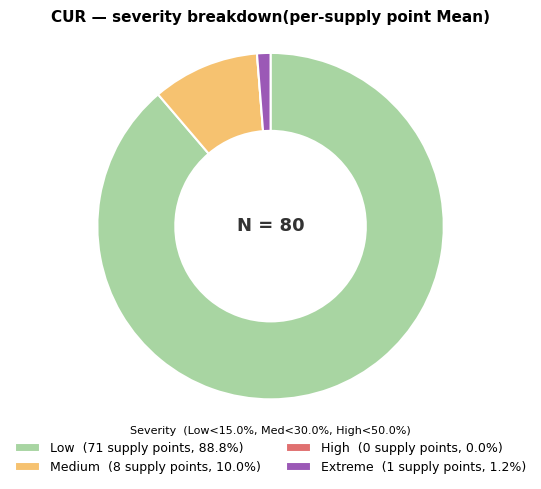

In [4]:
# Here all the thresholds are for the long-term analysis where we average per supply point over the entire measurement period
LongTerm_low_CUR = 15
LongTerm_mid_CUR = 30
LongTerm_high_CUR = 50

LongTerm_low_VUF = 1
LongTerm_mid_VUF = 2
LongTerm_high_VUF = 3

fig = _severity_donut_for_metric(avg_df, "cur_ratio", threshold=0, outdir=".", per_device=True, agg="mean", low=LongTerm_low_CUR, mid=LongTerm_mid_CUR, high=LongTerm_high_CUR)
#fig = _severity_donut_for_metric(avg_df, "vuf_magnitude", threshold=0, outdir=".", per_device=True, agg="mean", low=LongTerm_low_VUF, mid=LongTerm_mid_VUF, high=LongTerm_high_VUF)


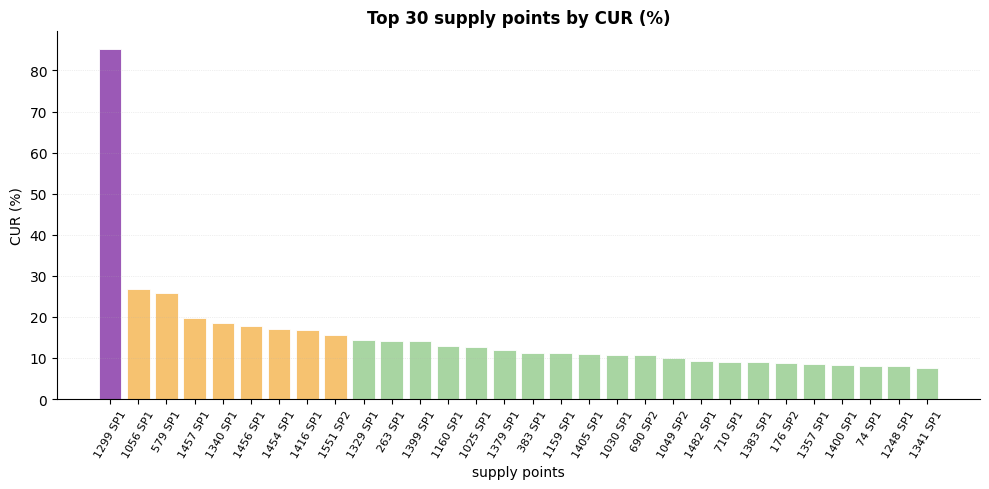

In [5]:
fig = barplot_by_device(avg_df, "cur_ratio", outdir=".", top_n=30, name_df=df_jn_filtered)
#fig = barplot_by_device(avg_df, "vuf_magnitude", outdir=".", top_n=30, name_df=df_jn_filtered)
#

## Per Timestamp Analysis (15min)

Here we look at the data in 15 min intervals.

FYI device 377/375/361 is causing the random spike in VUF

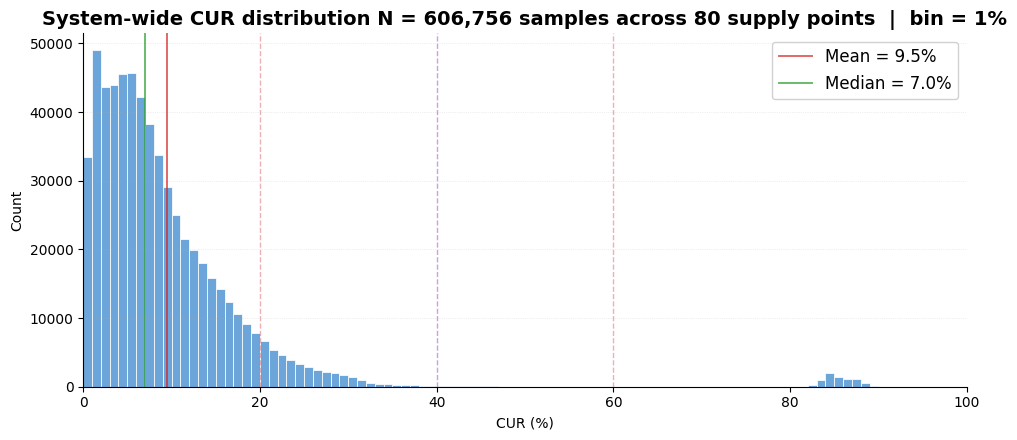

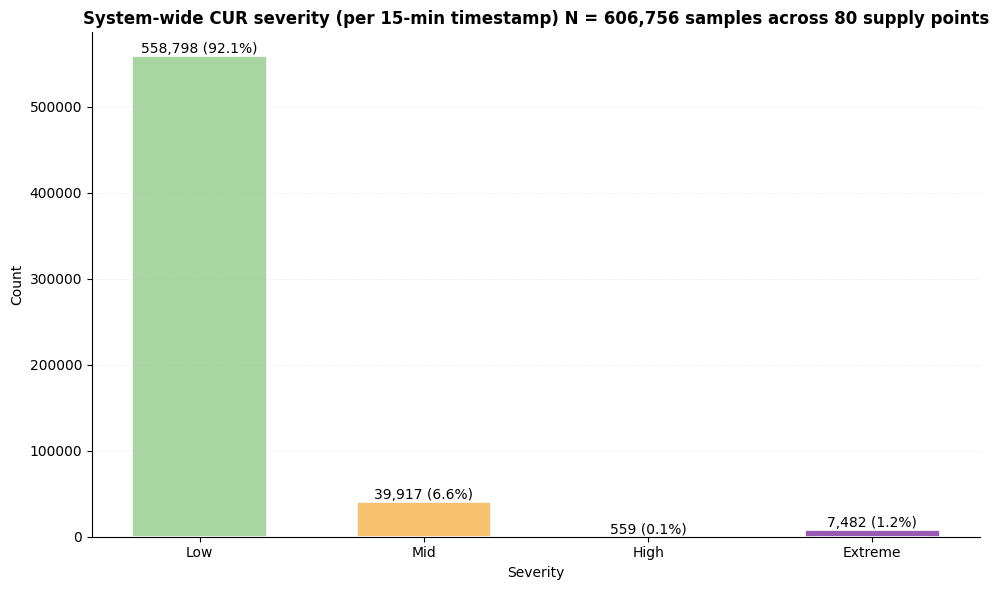

In [11]:
edges_ts_CUR    = [0.0, 20.0, 40.0, 60.0, 100.0 + 1e-9]
edges_ts_CURdev = [0.0, 10, 20, 30, (2/3)*100 + 1e-9]
edges_ts_VUF    = [0.0, 1, 2, 3, 100 + 1e-9]
labels = ["Low", "Mid", "High", "Extreme"]

# ---- histograms ----
fig = system_wide_histogram(
    df_jn_hi_load, metric_col="cur_ratio",
    bin_width_pct=1, max_pct=100, severity_edges=edges_ts_CUR,
)


# ---- severity bar charts ----
fig, counts, tmp = system_wide_severity_barchart_timestamp(
    df_jn_hi_load, metric_col="cur_ratio",
    edges=edges_ts_CUR, labels=labels, max_pct=100.0,
)


In [4]:
# --- Phase balance over whole period (cumulative) per device_id ---

# 1) device_id -> name map (from df_jn_filtered where you've already parsed the names)
name_map = (
    df_jn_filtered[["device_id", "name"]]
    .dropna(subset=["device_id", "name"])
    .assign(device_id=lambda d: d["device_id"].astype(str).str.strip(),
            name=lambda d: d["name"].astype(str).str.strip())
    .drop_duplicates("device_id")
    .set_index("device_id")["name"]
)

# 2) cumulative currents per device over the whole period
cur = df_jn_hi_load[["device_id", "Ia_avg", "Ib_avg", "Ic_avg"]].copy()
cur["device_id"] = cur["device_id"].astype(str).str.strip()
for c in ["Ia_avg", "Ib_avg", "Ic_avg"]:
    cur[c] = pd.to_numeric(cur[c], errors="coerce")

cur = cur.dropna(subset=["device_id", "Ia_avg", "Ib_avg", "Ic_avg"])

cum = cur.groupby("device_id")[["Ia_avg", "Ib_avg", "Ic_avg"]].sum()
cum = cum.rename(columns={"Ia_avg": "Ia_cum", "Ib_avg": "Ib_cum", "Ic_avg": "Ic_cum"})
cum["I_total_cum"] = cum[["Ia_cum", "Ib_cum", "Ic_cum"]].sum(axis=1)

# avoid divide-by-zero
cum = cum[cum["I_total_cum"] > 0].copy()

# 3) percentages A/B/C
cum["A_pct"] = (cum["Ia_cum"] / cum["I_total_cum"]) * 100.0
cum["B_pct"] = (cum["Ib_cum"] / cum["I_total_cum"]) * 100.0
cum["C_pct"] = (cum["Ic_cum"] / cum["I_total_cum"]) * 100.0

# 4) format "40/30/30" (A/B/C), rounded to whole %
cum["balance_ABC"] = (
    cum["A_pct"].round(0).astype(int).astype(str) + "/" +
    cum["B_pct"].round(0).astype(int).astype(str) + "/" +
    cum["C_pct"].round(0).astype(int).astype(str)
)

# 5) build final table: device_id, name, balance
out = cum.reset_index()
out["name"] = out["device_id"].map(name_map).fillna(out["device_id"])

phase_balance_list = out[["device_id", "name", "balance_ABC", "A_pct", "B_pct", "C_pct", "I_total_cum"]].copy()

# optional: sort by "most imbalanced" vs perfect 33/33/33 (simple max deviation)
phase_balance_list["max_dev_pct"] = phase_balance_list[["A_pct", "B_pct", "C_pct"]].sub(100/3).abs().max(axis=1)
phase_balance_list = phase_balance_list.sort_values("max_dev_pct", ascending=False)

phase_balance_list.head(100)


,device_id,name,balance_ABC,A_pct,B_pct,C_pct,I_total_cum,max_dev_pct
22,232,1299 SP1,90/5/5,90.135641,4.984619,4.879740,9.768316e+05,56.802307
55,377,579 SP1,43/40/17,43.065364,39.749035,17.185602,4.851631e+06,16.147732
77,448,1056 SP1,33/20/47,32.945762,20.187452,46.866786,2.196939e+05,13.533452
15,169,1457 SP1,38/41/21,37.998292,40.910779,21.090928,4.350606e+05,12.242405
20,223,1456 SP1,45/28/27,44.772619,28.286760,26.940622,4.997985e+05,11.439285
...,...,...,...,...,...,...,...,...
7,144,1484 SP1,34/33/34,33.791246,32.680636,33.528118,2.310274e+06,0.652697
44,354,1554 SP1,34/33/33,33.843773,32.998221,33.158006,2.686410e+06,0.510440
38,331,1551 SP1,33/33/34,32.837451,33.330891,33.831659,1.517070e+04,0.498325
48,365,1528 SP1,33/33/34,33.215733,32.959852,33.824414,3.911369e+05,0.491081


## Per a supply point

Here we look at the data per a supply point.

In [10]:
device_id = 448

metrics = ["cur_ratio"]


for metric_col in metrics:
    if metric_col == "cur_ratio":
        thresholds = {"mild": 20, "moderate": 40, "severe": 60}  # percent
    elif metric_col == "cur_dev_ratio":
        thresholds = {"mild": 10, "moderate": 20, "severe": 30}  # percent
    elif metric_col == "vuf_magnitude":
        thresholds = {"mild": 1, "moderate": 2, "severe": 3}      # percent

    outdir = f"./figs/device_{device_id}/{metric_col}"

    df_ready, mild_events, metrics = make_7_plots_from_df_jn(
        df_jn,
        device_id=device_id,
        metric_col=metric_col,
        thresholds=thresholds,
        outdir=outdir,
        dpi=250,
        timebase="15min",
        stat="avg",
        scale="none",
        name_df=df_jn_filtered,
    )

### Exceedance for multiple devices

Saved to ./figs/exceedance_multi_cur_ratio.png


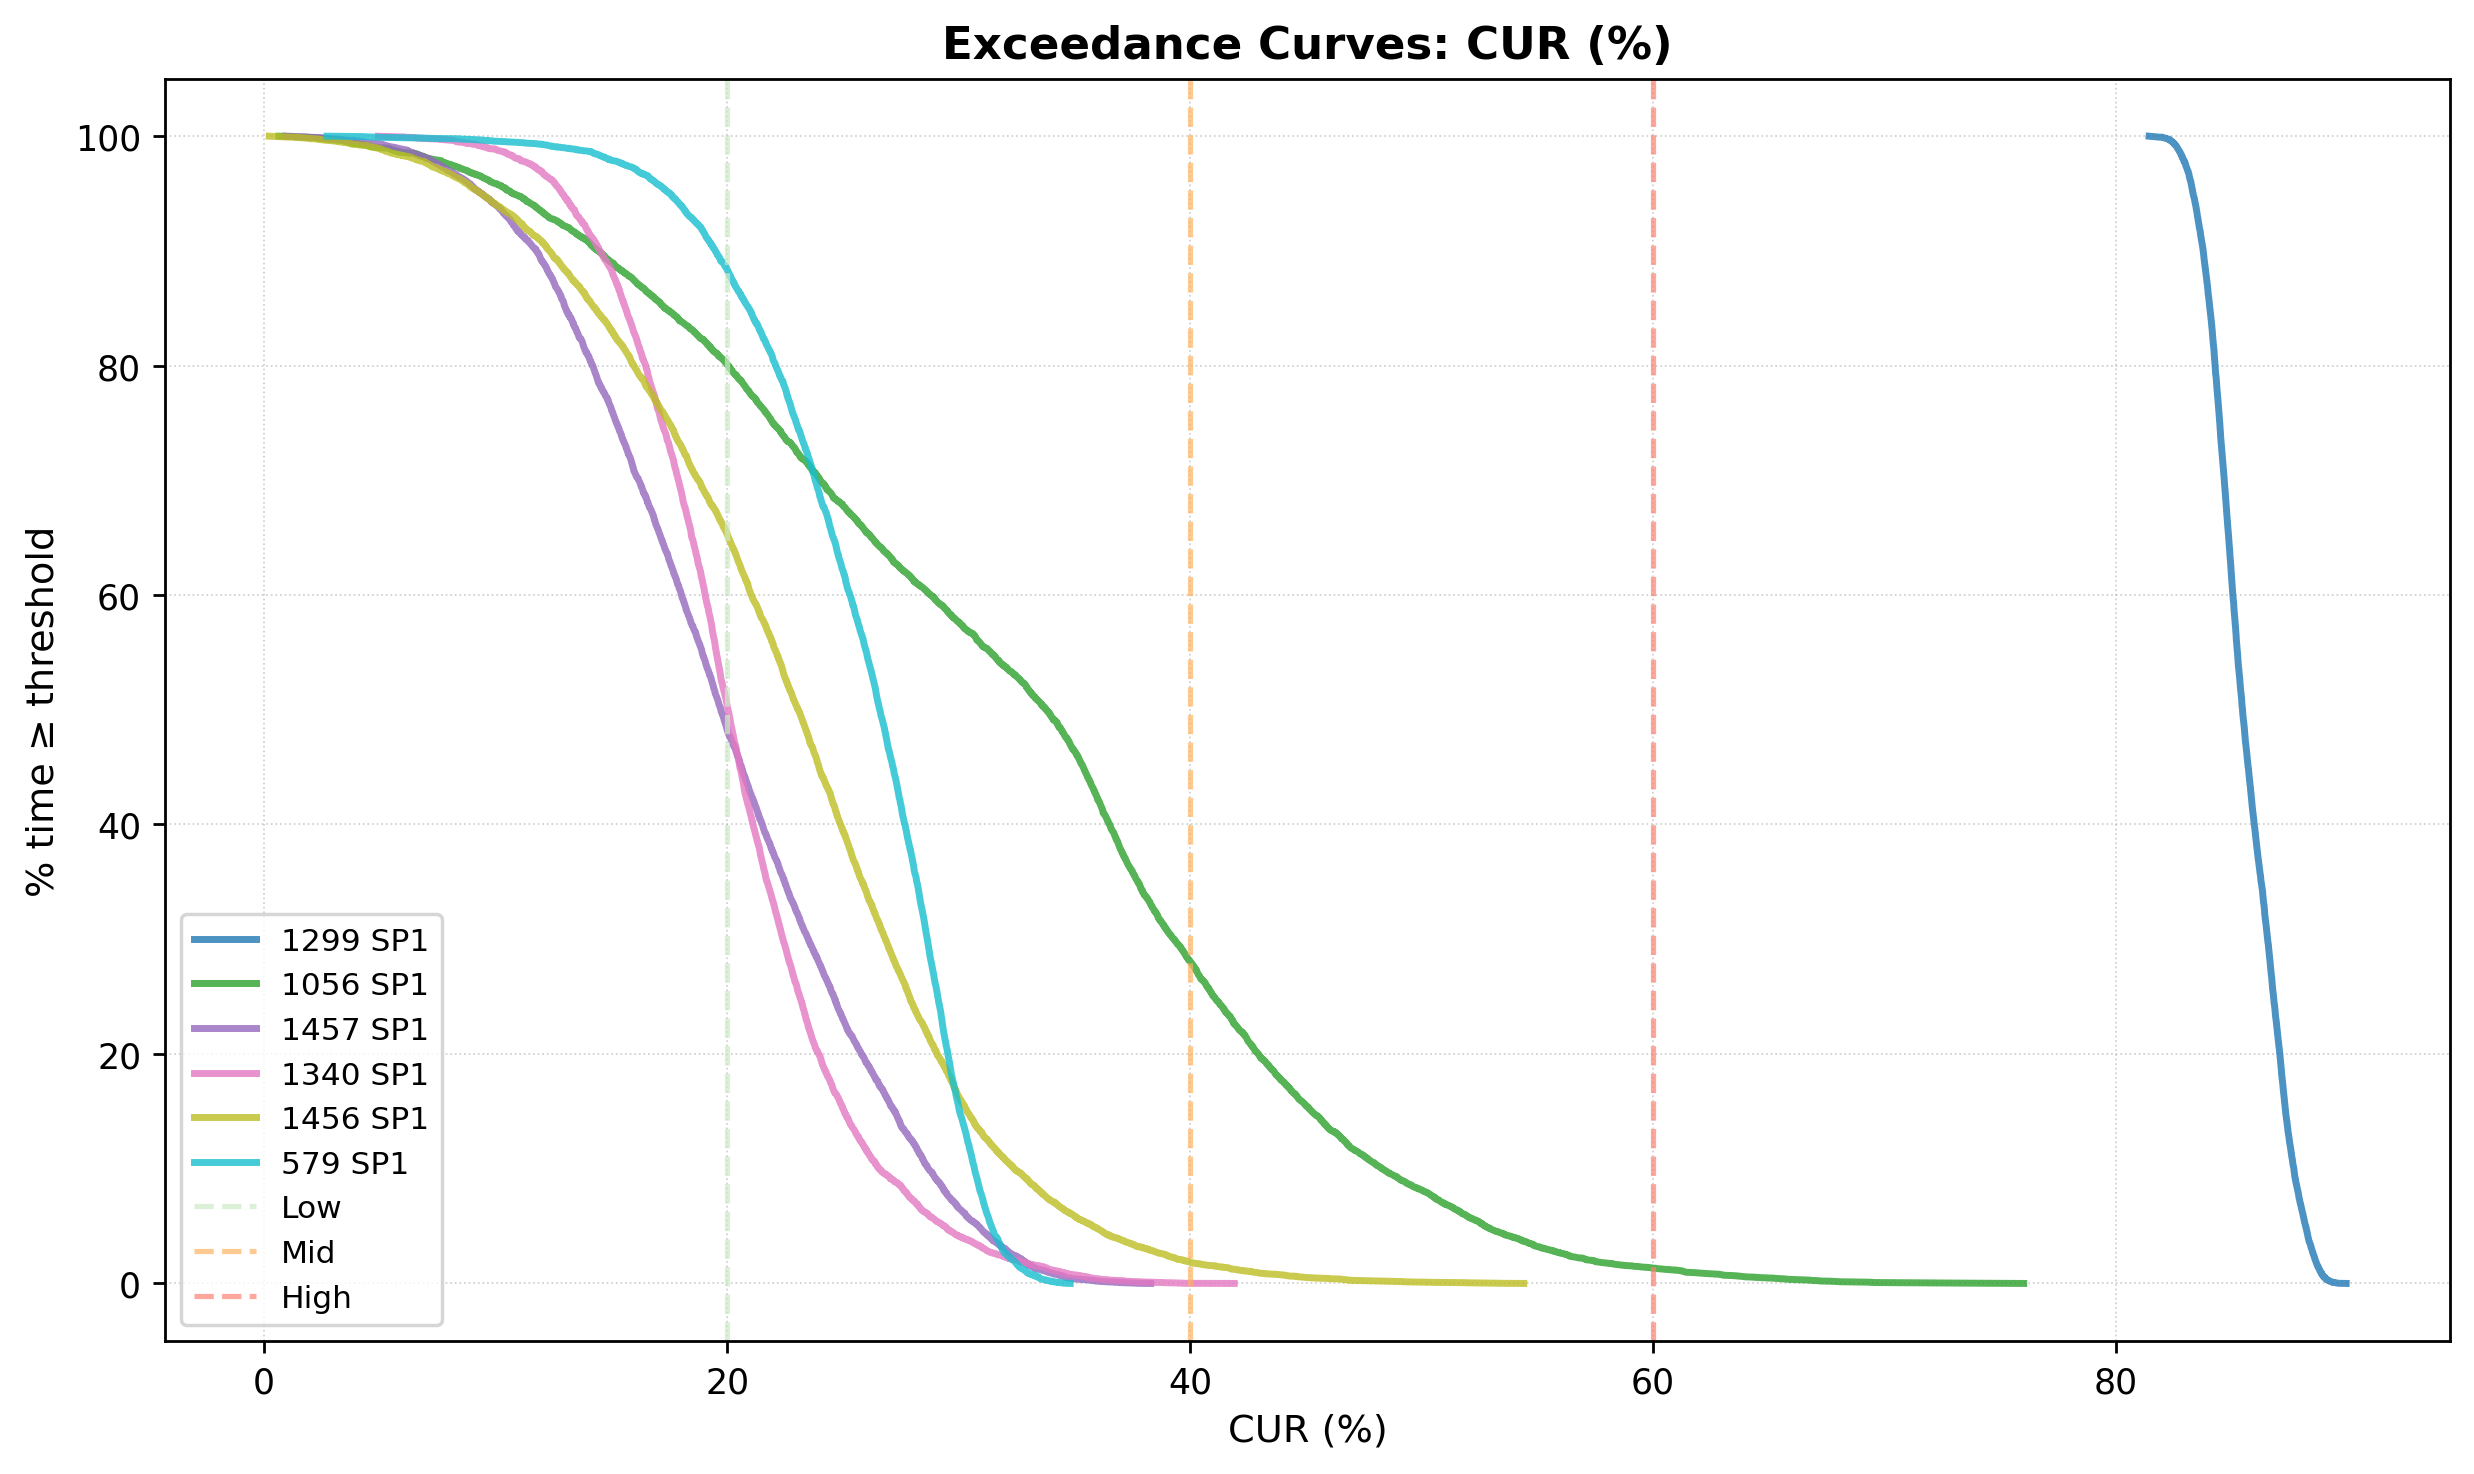

In [12]:
# COMMAND ----------
def plot_exceedance_multi_device(
    df_jn: pd.DataFrame,
    device_ids: list[int],
    metric_col: str,
    thresholds: dict,
    stat: str = "avg",
    start: str | None = None,
    end: str | None = None,
    scale: str = "auto",
    dpi: int = 200,
    output_path: str | None = None,
    *,
    name_df: pd.DataFrame | None = None,
):
    """
    Plot exceedance curves for multiple devices on the same figure.
    
    Parameters:
    - df_jn: raw janitza dataframe
    - device_ids: list of device IDs to plot (e.g., [5, 232, 386])
    - metric_col: which metric to use ("cur_ratio", "cur_dev_ratio", "vuf_magnitude")
    - thresholds: dict like {"low": 20, "mid": 40, "high": 60} for severity bins
    - stat: "avg", "min", or "max"
    - start/end: optional time filtering
    - scale: "auto", "fraction_to_percent", or "none"
    - dpi: figure resolution
    - output_path: where to save (optional)
    - name_df: df_jn_filtered for device name lookup
    
    Returns: matplotlib Figure
    """
    if plt is None:
        print("matplotlib not available.")
        return None
    
    # Build device_id -> name mapping
    label_map = {}
    if name_df is not None and "device_id" in name_df.columns and "name" in name_df.columns:
        tmp = name_df[["device_id", "name"]].copy()
        tmp["device_id"] = tmp["device_id"].astype(str).str.strip()
        tmp["name"] = tmp["name"].astype(str).str.strip()
        label_map = (
            tmp.dropna(subset=["name"])
               .drop_duplicates("device_id")
               .set_index("device_id")["name"]
               .to_dict()
        )
    
    fig, ax = plt.subplots(figsize=(10, 6), dpi=dpi)
    
    # Color palette for multiple devices
    colors = plt.cm.tab10(np.linspace(0, 1, len(device_ids)))
    
    for idx, device_id in enumerate(device_ids):
        try:
            # Prepare data for this device
            df_ready = df_jn_to_report_df(
                df_jn,
                device_id=device_id,
                metric_col=metric_col,
                stat=stat,
                start=start,
                end=end,
                scale=scale,
            )
            
            if df_ready.empty or "imbalance" not in df_ready.columns:
                print(f"No data for device {device_id}, skipping.")
                continue
            
            series = df_ready["imbalance"].dropna()
            if series.empty:
                print(f"No valid imbalance data for device {device_id}, skipping.")
                continue
            
            # Compute exceedance curve
            vals = np.sort(series.to_numpy())
            exc = 1.0 - np.arange(1, len(vals) + 1) / float(len(vals))
            
            # Get device label
            device_str = str(device_id).strip()
            label = label_map.get(device_str, f"Device {device_id}")
            
            # Plot
            ax.plot(vals, exc * 100.0, color=colors[idx], linewidth=2, 
                   label=label, alpha=0.8)
            
        except Exception as e:
            print(f"Error processing device {device_id}: {e}")
            continue
    
    # Add threshold lines for three severity boundaries (Low, Mid, High only)
    # Colors match your severity donut charts
    severity_colors = {
        "low": "#ccebc5",    # Light green (Low)
        "mid": "#fdb462",    # Orange (Mid)
        "high": "#fb8072",   # Red (High)
    }
    
    # Plot three threshold lines
    for band in ["low", "mid", "high"]:
        if band in thresholds:
            thr = thresholds[band]
            color = severity_colors.get(band, "#ccc")
            ax.axvline(thr, color=color, linestyle="--", alpha=0.7, linewidth=1.5,
                      label=band.capitalize())
    
    # Formatting

    if metric_col == "cur_ratio":
        metric_display = "CUR (%)" if scale != "none" else "CUR (%)"
    elif metric_col == "cur_dev_ratio":
        metric_display = "CUR Deviation (%)" if scale != "none" else "CUR Deviation (%)"
    elif metric_col == "vuf_magnitude":
            metric_display = "VUF (%)" if scale != "none" else "VUF (%)"

    ax.set_xlabel(metric_display, fontsize=11)
    ax.set_ylabel("% time ≥ threshold", fontsize=11)
    ax.set_title(f"Exceedance Curves: {metric_display}", fontsize=13, fontweight="bold")
    ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.6)
    ax.legend(loc="best", frameon=True, fontsize=9)
    
    fig.tight_layout()
    
    if output_path:
        fig.savefig(output_path, bbox_inches="tight", dpi=dpi)
        print(f"Saved to {output_path}")
    
    return fig


# COMMAND ----------
# Example usage with three severity boundaries

# Choose your devices
devices_to_compare = [232, 448, 169, 371,223,377]

# CUR bins: [0,20), [20,40), [40,60), [60,100]
thresholds_cur = {
    "low": 20,       # Low boundary
    "mid": 40,       # Mid boundary
    "high": 60,      # High boundary
}

fig = plot_exceedance_multi_device(
    df_jn=df_jn,
    device_ids=devices_to_compare,
    metric_col="cur_ratio",
    thresholds=thresholds_cur,
    stat="avg",
    scale="none",
    dpi=250,
    output_path="./figs/exceedance_multi_cur_ratio.png",
    name_df=df_jn_filtered,
)


# VUF bins: [0,1), [1,2), [2,3), [3,100]
thresholds_vuf = {
    "low": 1,        # Low boundary
    "mid": 2,        # Mid boundary
    "high": 3,       # High boundary
}

# fig = plot_exceedance_multi_device(
#     df_jn=df_jn,
#     device_ids=devices_to_compare,
#     metric_col="vuf_magnitude",
#     thresholds=thresholds_vuf,
#     stat="avg",
#     scale="none",
#     dpi=250,
#     output_path="./figs/exceedance_multi_vuf_magnitude.png",
#     name_df=df_jn_filtered,
# )

In [ ]:
# --- compute per-device timeframe from df_jn ---
tmp = df_jn_filtered[["device_id", "ts", "name", "device_type_name"]].copy()
tmp["device_id"] = pd.to_numeric(tmp["device_id"], errors="coerce").astype("Int64")
tmp["ts"] = pd.to_datetime(tmp["ts"], errors="coerce")
tmp = tmp.dropna(subset=["device_id", "ts"])

# first/last per device
tf = (
    tmp.groupby("device_id")
       .agg(
           first_ts=("ts", "min"),
           last_ts=("ts", "max"),
           name=("name", "first"),
           device_type_name=("device_type_name", "first"),
           n_samples=("ts", "count"),
       )
       .reset_index()
)

tf["duration"] = tf["last_ts"] - tf["first_ts"]
tf["duration_days"] = tf["duration"].dt.total_seconds() / 86400.0

# --- top 5 shortest / longest timeframes ---
shortest5 = tf.sort_values(["duration", "n_samples"], ascending=[True, True]).head(200)
longest5  = tf.sort_values(["duration", "n_samples"], ascending=[False, False]).head(10)

print("\nTop 5 SHORTEST device timeframes:")
display(shortest5[["device_id", "name", "device_type_name", "first_ts", "last_ts", "duration", "duration_days", "n_samples"]])

print("\nTop 5 LONGEST device timeframes:")
display(longest5[["device_id", "name", "device_type_name", "first_ts", "last_ts", "duration", "duration_days", "n_samples"]])

#


Top 5 SHORTEST device timeframes:


,device_id,name,device_type_name,first_ts,last_ts,duration,duration_days,n_samples
48,360,1441 SP1,UMG 96RM-E,2025-09-24 16:17:33+00:00,2025-10-31 23:45:00+00:00,37 days 07:27:27,37.310729,3583
1,4,29 SP1,UMG 801 Measurement Group,2025-08-01 00:00:00+00:00,2025-09-25 05:30:00+00:00,55 days 05:30:00,55.229167,5277
38,323,1534 SP1,UMG 512,2025-07-31 23:59:00.159895718+00:00,2025-10-31 23:44:00.118920582+00:00,91 days 23:44:59.959024864,91.989583,11574
9,132,670 SP1,UMG 605,2025-08-01 00:00:00.161219630+00:00,2025-10-31 23:45:00.133601666+00:00,91 days 23:44:59.972382036,91.989583,11023
37,317,1454 SP1,UMG 801 Measurement Group,2025-08-01 00:00:00+00:00,2025-10-31 23:45:00+00:00,91 days 23:45:00,91.989583,7677
...,...,...,...,...,...,...,...,...
40,328,1532 SP1,UMG 801 Measurement Group,2025-08-01 00:00:00+00:00,2025-10-31 23:45:00+00:00,91 days 23:45:00,91.989583,10735
39,324,1534 SP2,UMG 512,2025-07-31 23:59:00.159907868+00:00,2025-10-31 23:45:00.141873128+00:00,91 days 23:45:59.981965260,91.990278,20039
10,133,537 SP1,UMG 605,2025-07-31 23:00:00.089476618+00:00,2025-10-31 23:44:00.122588900+00:00,92 days 00:44:00.033112282,92.030556,11058
11,134,688 SP1,UMG 605,2025-07-31 23:00:00.071530596+00:00,2025-10-31 23:44:00.122765060+00:00,92 days 00:44:00.051234464,92.030556,11057



Top 5 LONGEST device timeframes:


,device_id,name,device_type_name,first_ts,last_ts,duration,duration_days,n_samples
6,42,76 SP1,UMG 605,2025-07-31 23:00:00.016070782+00:00,2025-10-31 23:44:00.122709640+00:00,92 days 00:44:00.106638858,92.030557,11056
11,134,688 SP1,UMG 605,2025-07-31 23:00:00.071530596+00:00,2025-10-31 23:44:00.122765060+00:00,92 days 00:44:00.051234464,92.030556,11057
10,133,537 SP1,UMG 605,2025-07-31 23:00:00.089476618+00:00,2025-10-31 23:44:00.122588900+00:00,92 days 00:44:00.033112282,92.030556,11058
39,324,1534 SP2,UMG 512,2025-07-31 23:59:00.159907868+00:00,2025-10-31 23:45:00.141873128+00:00,91 days 23:45:59.981965260,91.990278,20039
40,328,1532 SP1,UMG 801 Measurement Group,2025-08-01 00:00:00+00:00,2025-10-31 23:45:00+00:00,91 days 23:45:00,91.989583,10735
51,365,1528 SP1,UMG 801 Measurement Group,2025-08-01 00:00:00+00:00,2025-10-31 23:45:00+00:00,91 days 23:45:00,91.989583,9803
79,440,604 SP2,UMG 801 Measurement Group,2025-08-01 00:00:00+00:00,2025-10-31 23:45:00+00:00,91 days 23:45:00,91.989583,9726
0,1,29 SP1 L2,UMG 96RM-E,2025-08-01 00:00:00+00:00,2025-10-31 23:45:00+00:00,91 days 23:45:00,91.989583,8832
2,12,411 SP1,UMG 801 Measurement Group,2025-08-01 00:00:00+00:00,2025-10-31 23:45:00+00:00,91 days 23:45:00,91.989583,8832
12,144,1484 SP1,UMG 96RM-E,2025-08-01 00:00:00+00:00,2025-10-31 23:45:00+00:00,91 days 23:45:00,91.989583,8832
